In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , PolynomialFeatures

In [4]:
df = pd.read_csv("data/clash_of_clans_upgrades.csv")
df.head()

,upgrade_id,building_type,town_hall_level,current_level,builder_boost_percent,builder_count,upgrade_cost_elixir,upgrade_time_hours
0,1,Wizard Tower,1,4,50,2,114000,9.19
1,2,Air Defense,7,10,30,2,1191000,68.22
2,3,Cannon,14,15,0,1,1292000,80.54
3,4,Archer Tower,8,13,50,2,876000,41.39
4,5,Dark Elixir Storage,11,4,50,6,482000,24.51


In [5]:
print(df.isnull().sum())
print(df.info())

upgrade_id               0
building_type            0
town_hall_level          0
current_level            0
builder_boost_percent    0
builder_count            0
upgrade_cost_elixir      0
upgrade_time_hours       0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   upgrade_id             1000 non-null   int64  
 1   building_type          1000 non-null   str    
 2   town_hall_level        1000 non-null   int64  
 3   current_level          1000 non-null   int64  
 4   builder_boost_percent  1000 non-null   int64  
 5   builder_count          1000 non-null   int64  
 6   upgrade_cost_elixir    1000 non-null   int64  
 7   upgrade_time_hours     1000 non-null   float64
dtypes: float64(1), int64(6), str(1)
memory usage: 62.6 KB
None


In [18]:
# X = df[["town_hall_level","current_level","building_type"]]
# y = df["upgrade_cost_elixir"]
X = df[['building_type', 'town_hall_level', 'current_level', 'builder_boost_percent']]
y = df['upgrade_time_hours']
print(f"Loaded {len(df)} upgrade into pipeline")

Loaded 1000 upgrade into pipeline


In [20]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state=43)
print(f"Training on this Much of {len(X_train)} rows")
print(f"Testing on this Much of {len(X_test)} rows")

Training on this Much of 800 rows
Testing on this Much of 200 rows


In [ ]:
from sklearn import pipeline


preprocessor = ColumnTransformer(
    transformers=[
        ('num','passthrough',['town_hall_level','current_level']),
        ('cat',OneHotEncoder(handle_unknown="ignore"),['building_type'])
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])


In [21]:
# Linear Regression
pre_linear = ColumnTransformer(
    [
        ('num','passthrough',['town_hall_level', 'current_level', 'builder_boost_percent']),
        ('cat',OneHotEncoder(handle_unknown="ignore"),["building_type"])
    ]
)
pipe_lin = Pipeline([
    ('pre',pre_linear),('model',LinearRegression())
])
pipe_lin.fit(X_train,y_train)
pred_lin = pipe_lin.predict(X_test)

In [10]:
# Polynomial Regression
pre_poly = ColumnTransformer([
    ('num',Pipeline([('poly',PolynomialFeatures(degree=3,include_bias=False))]),['town_hall_level','current_level']),
    ('cat',OneHotEncoder(handle_unknown='ignore'),["building_type"])
])
pipe_poly = Pipeline([
    ("pre",pre_poly),('model',LinearRegression())
])
pipe_poly.fit(X_train,y_train)
pred_poly = pipe_poly.predict(X_test)

In [22]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor


pipe_rfr = Pipeline([
    ('pre',pre_linear),('model',RandomForestRegressor(random_state=43))
])
pipe_rfr.fit(X_train,y_train)
pred_rfr = pipe_rfr.predict(X_test)

In [23]:
linear_error = mean_absolute_error(y_test,pred_lin)
polynomial_error = mean_absolute_error(y_test,pred_poly)
Random_error = mean_absolute_error(y_test,pred_rfr)

print(linear_error)
print(polynomial_error)
print(Random_error)

7.191370966662562
7.037856797409086
2.683060691071424


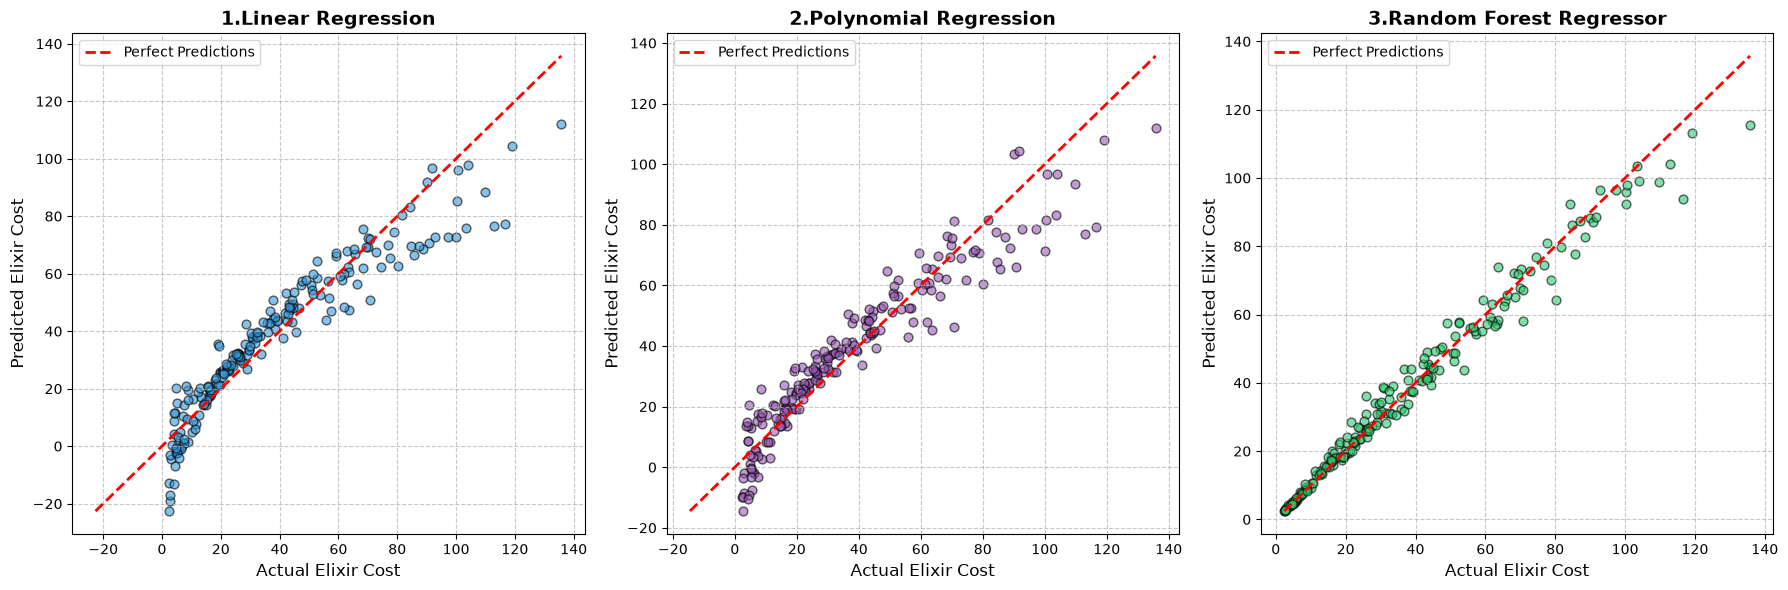

In [24]:
fig, axes = plt.subplots(1,3,figsize = (18,6))
def plot_prediction(ax,predictions,title ,color):
    ax.scatter(y_test,predictions,alpha = 0.6,color=color,edgecolor ='k',s=40)

    min_val = min(y_test.min(),predictions.min())
    max_val = max(y_test.max(),predictions.max())
    ax.plot([min_val,max_val],[min_val,max_val],'--r',lw = 2 ,label = "Perfect Predictions")
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual Elixir Cost', fontsize=12)
    ax.set_ylabel('Predicted Elixir Cost', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plot_prediction(axes[0],pred_lin,'1.Linear Regression','#3498db')
plot_prediction(axes[1],pred_poly,'2.Polynomial Regression','#9b59b6')
plot_prediction(axes[2],pred_rfr,'3.Random Forest Regressor','#2ecc71')

plt.tight_layout()
plt.show()

In [25]:
random_forest_errors = mean_absolute_error(y_test,pred_rfr)
print(f"The model's predictions are off by an average of {random_forest_errors:,.0f} Hours.")

The model's predictions are off by an average of 3 Hours.


In [26]:
import joblib
joblib.dump(pipe_rfr,'coc_hours_model.joblib')

['coc_hours_model.joblib']